In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
cotacoes = pd.read_excel('economatica(3).xlsx', sheet_name='SLCT3B', header=3, index_col=0, na_values=['-'])
# A diferença entre o fechamento ajustado e fechamento é que o fechamento ajustado leva em consideração a distribuicão de dividendos e desdobramentos de ações,
# enquanto o fechamento não leva em consideração esses fatores. A vantagem do fechamento ajustado é que ele evita distorções nos preços causadas por esses eventos.


In [15]:
nomes_novos = []
for cotacao in cotacoes.columns:
    nomes_novos.append(cotacao.split("\n")[-1])
cotacoes.columns = nomes_novos

In [16]:
cotacoes = cotacoes.dropna()

In [17]:
base1 = cotacoes/cotacoes.iloc[0]

Text(0, 0.5, 'Índice (base 1)')

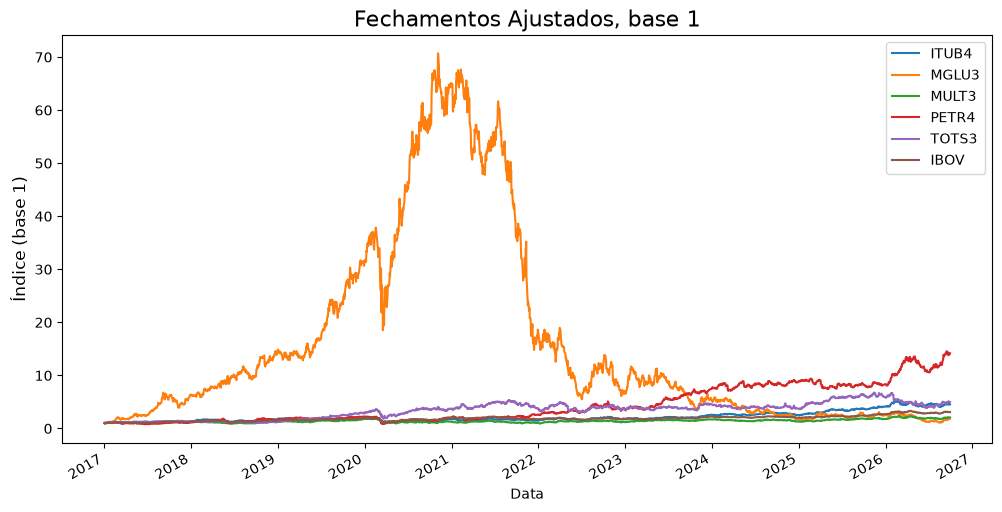

In [18]:
grafico = base1.plot(figsize=(12, 6))
grafico.set_title('Fechamentos Ajustados, base 1', fontsize=16)
grafico.set_ylabel("Índice (base 1)", fontsize=12)

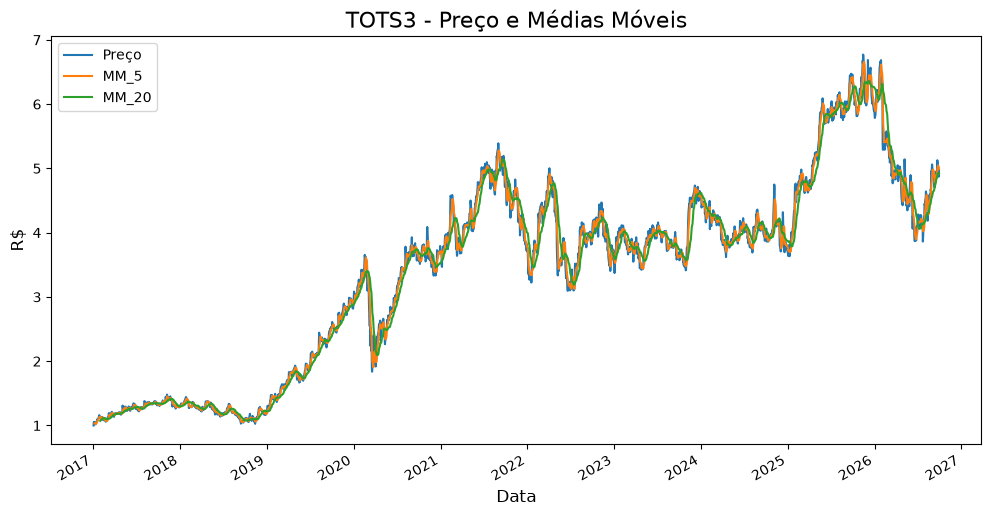

In [19]:
ativo = "TOTS3"
media_movel = pd.DataFrame({
    "Preço": base1[ativo],
    "MM_5": base1[ativo].rolling(window=5).mean(),
    "MM_20": base1[ativo].rolling(window=20).mean(),
}
)
grafico_totvs = media_movel.plot(figsize=(12, 6))
grafico_totvs.set_title("TOTS3 - Preço e Médias Móveis", fontsize=16)
grafico_totvs.set_ylabel("R$", fontsize=12)
grafico_totvs.set_xlabel("Data", fontsize=12)
plt.show()

In [20]:
retornos_simples = base1.pct_change()
retornos_logaritmos = np.log(base1) -np.log(base1.shift(1))
retornos_simples_anualizados = ((1+retornos_simples.mean()) ** 252 - 1 ) * 100
retornos_logaritmos_anualizados = ( retornos_logaritmos.mean() * 252 ) * 100
# Os retornos simples e logaritmos não são iguais, mas são próximos.

In [21]:
media_logretorno = retornos_logaritmos.mean() *252
desvio_padrao_logretorno = retornos_logaritmos.std() * np.sqrt(252)
selic = 0.1375  
sharpe_ratio = (media_logretorno - selic) / desvio_padrao_logretorno
# A que melhor performou foi a PETR4, com sharpe de 0,33, ou seja, para cada unidade de risco, houve 0,33 de retorno acima da taxa selic.

In [22]:
correlacao = retornos_logaritmos.corr()
# A matriz de correlação mostra a relação entre os retornos dos ativos, quanto mais próximo de 1 ou -1, mais correlacionados estão os ativos.
# Os resultados mostram que a maior correlação entre ativos é entre ITUB4 e MULT3, com 0,57. Fora isso, todos ativos possuem correlação baixa entre si, porém correlação maior com o IBOV.

In [ ]:
acoes = ['ITUB4', 'MGLU3', 'MULT3','PETR4','TOTS3']
portfolio = pd.Series([0.15, 0, 0, 0.7, 0.15], index=['ITUB4', 'MGLU3', 'MULT3','PETR4','TOTS3']) # Únicos 3 ativos com sharpe positivo, com destaque em PETR4, que é o ativo com maior sharpe ratio.
retorno_portfolio = retornos_simples[acoes] @ portfolio
retorno_portfolio.to_csv('ret_portfolio.xlsx', index = True)
media_ret_portfolio = retorno_portfolio.mean() * 252
desvio_padrao_portfolio = retorno_portfolio.std() * np.sqrt(252)

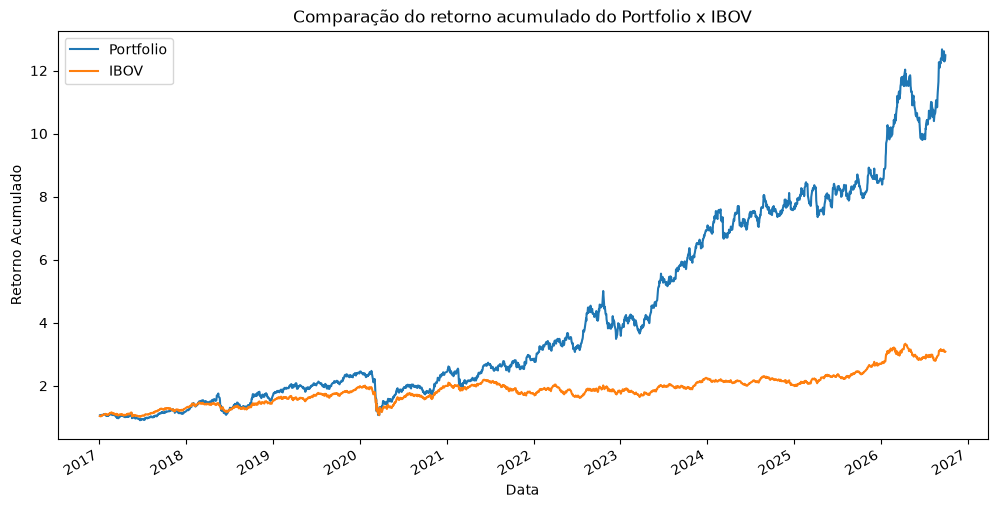

In [24]:
ret_acumulado_portfolio = (1 + retorno_portfolio).cumprod()
ret_acumulado_ibov = (1 + retornos_simples['IBOV']).cumprod()
ret_acumulado_portfolio.to_csv('ret_acumulado_portfolio.csv', index= True)
ret_acumulado_ibov.to_csv('ret_acumulado_ibov.csv', index= True)
grafico_portfolio = pd.DataFrame({
    "Portfolio": ret_acumulado_portfolio,
    "IBOV": ret_acumulado_ibov
}).plot(figsize=(12, 6))

grafico_portfolio.set_title("Comparação do retorno acumulado do Portfolio x IBOV")
grafico_portfolio.set_ylabel("Retorno Acumulado")
grafico_portfolio.set_xlabel("Data")
plt.show()

# Sim, o portfolio superou o mercado, visto que atingiu um retorno de 12 vezes, enquanto o IBOV ficou perto de 2 vezes.